<a href="https://colab.research.google.com/github/eshikaalam/SupervisedCode/blob/main/SupervisedIntegratedFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Classes: ['Double', 'Empty', 'Single']
Using Device: cuda
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 179MB/s]



Epoch [1/30]
Train Loss: 0.6496
Train Accuracy: 72.18%
Validation Loss: 1.0501
Validation Accuracy: 78.43%

Epoch [2/30]
Train Loss: 0.2306
Train Accuracy: 91.84%
Validation Loss: 0.3203
Validation Accuracy: 87.25%

Epoch [3/30]
Train Loss: 0.2729
Train Accuracy: 91.84%
Validation Loss: 0.7157
Validation Accuracy: 76.47%

Epoch [4/30]
Train Loss: 0.1603
Train Accuracy: 95.61%
Validation Loss: 0.4170
Validation Accuracy: 82.35%

Epoch [5/30]
Train Loss: 0.1553
Train Accuracy: 95.61%
Validation Loss: 3.2442
Validation Accuracy: 65.69%

Epoch [6/30]
Train Loss: 0.1692
Train Accuracy: 94.35%
Validation Loss: 0.2189
Validation Accuracy: 95.10%

Epoch [7/30]
Train Loss: 0.1469
Train Accuracy: 94.14%
Validation Loss: 0.4595
Validation Accuracy: 87.25%

Epoch [8/30]
Train Loss: 0.1420
Train Accuracy: 95.61%
Validation Loss: 1.7646
Validation Accuracy: 68.63%

Epoch [9/30]
Train Loss: 0.1683
Train Accuracy: 93.51%
Validation Loss: 1.2128
Validation Accuracy: 73.53%

Epoch [10/30]
Train Loss: 0

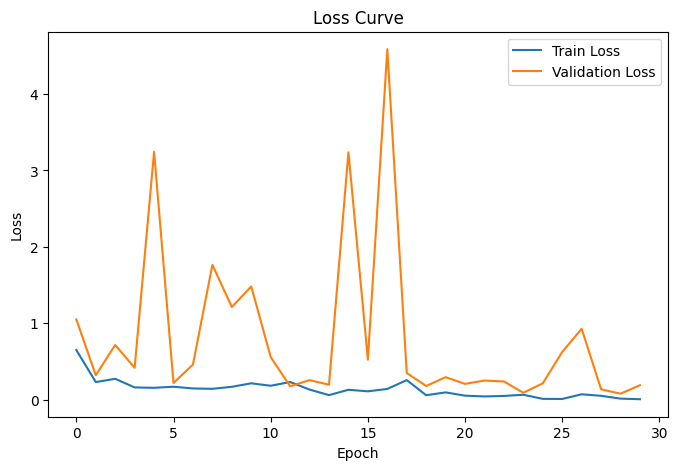

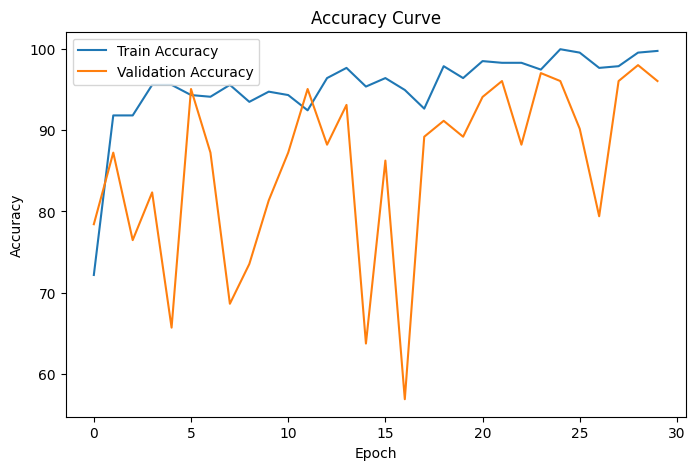

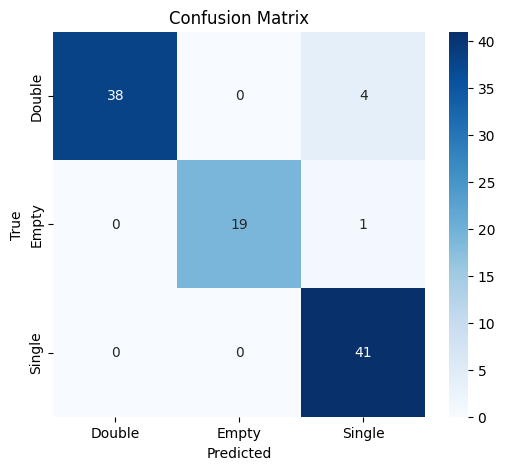


RESULTS TABLE

Voltage     Model                    ssDNA     dsDNA     Empty     Accuracy    F1 Score
100 mV      VGG19 Integrated FM      90.48     95.00     100.00    95.15       0.9556

Classification Report

              precision    recall  f1-score   support

      Double       1.00      0.90      0.95        42
       Empty       1.00      0.95      0.97        20
      Single       0.89      1.00      0.94        41

    accuracy                           0.95       103
   macro avg       0.96      0.95      0.96       103
weighted avg       0.96      0.95      0.95       103



In [ ]:
# Mount Google Drive
# ===============================
from google.colab import drive
drive.mount('/content/drive')
# ============================================================
# INSTALL REQUIRED PACKAGES
# ============================================================

!pip install torch torchvision scikit-learn seaborn

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import vgg19, VGG19_Weights

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)

# ============================================================
# RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ============================================================
# DATASET PATH
# ============================================================

DATA_PATH = "/content/drive/MyDrive/AAV data/images/100mV/4s_segment_trans/train_val_photos"

# ============================================================
# IMAGE TRANSFORMATIONS
# ============================================================

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor()
])

# ============================================================
# LOAD DATASET
# ============================================================

dataset = ImageFolder(
    root=DATA_PATH,
    transform=transform
)

# ============================================================
# CLASS NAMES
# ============================================================

class_names = dataset.classes

print("Classes:", class_names)

# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(

    dataset,
    [train_size, val_size, test_size]
)

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

# ============================================================
# VGG19 INTEGRATED FM MODEL
# ============================================================

class VGG19_FM(nn.Module):

    def __init__(self, num_classes=3):

        super(VGG19_FM, self).__init__()

        # ----------------------------------------------------
        # PRETRAINED VGG19
        # ----------------------------------------------------

        base_model = vgg19(
            weights=VGG19_Weights.IMAGENET1K_V1
        )

        # ----------------------------------------------------
        # FEATURE EXTRACTOR
        # ----------------------------------------------------

        self.features = base_model.features

        # ----------------------------------------------------
        # FEATURE MODULE (FM)
        # ----------------------------------------------------

        self.feature_module = nn.Sequential(

            nn.Conv2d(
                in_channels=512,
                out_channels=512,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(512),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=512,
                out_channels=512,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(512),

            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((7,7))
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(512*7*7, 4096),

            nn.ReLU(True),

            nn.Dropout(0.5),

            nn.Linear(4096, 1024),

            nn.ReLU(True),

            nn.Dropout(0.5),

            nn.Linear(1024, num_classes)
        )

    # ========================================================
    # FORWARD FUNCTION
    # ========================================================

    def forward(self, x):

        x = self.features(x)

        x = self.feature_module(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

# ============================================================
# MODEL INITIALIZATION
# ============================================================

model = VGG19_FM(num_classes=3)

model = model.to(device)

# ============================================================
# LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# ============================================================
# STORAGE
# ============================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total

    avg_loss = total_loss / len(loader)

    return avg_loss, accuracy

# ============================================================
# TRAINING LOOP
# ============================================================

EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    # ========================================================
    # VALIDATION
    # ========================================================

    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")

# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.show()

# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy Curve")

plt.legend()

plt.show()

# ============================================================
# TEST EVALUATION
# ============================================================

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# PERFORMANCE METRICS
# ============================================================

overall_acc = np.trace(cm) / np.sum(cm) * 100

f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

# ============================================================
# RESULTS TABLE
# ============================================================

print("\n====================================================")
print("RESULTS TABLE")
print("====================================================\n")

print(
    f"{'Voltage':<12}"
    f"{'Model':<25}"
    f"{'ssDNA':<10}"
    f"{'dsDNA':<10}"
    f"{'Empty':<10}"
    f"{'Accuracy':<12}"
    f"{'F1 Score'}"
)

print(
    f"{'100 mV':<12}"
    f"{'VGG19 Integrated FM':<25}"
    f"{per_class_acc[0]:<10.2f}"
    f"{per_class_acc[1]:<10.2f}"
    f"{per_class_acc[2]:<10.2f}"
    f"{overall_acc:<12.2f}"
    f"{f1:.4f}"
)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)